In [7]:
import pandas as pd
import numpy as np

print("Loading data...")
df = pd.read_csv('cs-training.csv')


if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)


print(f"Dataset Shape: {df.shape}")
df.head()

Loading data...
Dataset Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']


print("Splitting data...")
# stratify=y ensures the test set has the same ratio of defaulters as the training set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


print("Imputing missing values...")
imputer = SimpleImputer(strategy='median')


X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

X_train = pd.DataFrame(X_train_imputed, columns=X.columns)
X_test = pd.DataFrame(X_test_imputed, columns=X.columns)

print("Data successfully split and imputed!")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Splitting data...
Imputing missing values...
Data successfully split and imputed!
Training data shape: (120000, 10)
Testing data shape: (30000, 10)


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

print("Tuning and training the Random Forest model...")
print("(This step tests multiple models and may take 1-3 minutes depending on your computer)")

rf = RandomForestClassifier(class_weight='balanced', random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_grid, 
    n_iter=5, 
    scoring='roc_auc', 
    cv=3, 
    random_state=42, 
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_

print("\nTraining Complete!")
print(f"Best parameters found: {random_search.best_params_}")

Tuning and training the Random Forest model...
(This step tests multiple models and may take 1-3 minutes depending on your computer)

Training Complete!
Best parameters found: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}


Matplotlib is building the font cache; this may take a moment.



--- Standard Evaluation (50% Threshold) ---
ROC-AUC Score: 0.8654

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.81      0.89     27995
           1       0.22      0.76      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.78      0.61     30000
weighted avg       0.93      0.80      0.85     30000


--- Evaluation with Custom Threshold (40.0%) ---
              precision    recall  f1-score   support

           0       0.99      0.72      0.83     27995
           1       0.18      0.85      0.29      2005

    accuracy                           0.73     30000
   macro avg       0.58      0.78      0.56     30000
weighted avg       0.93      0.73      0.80     30000



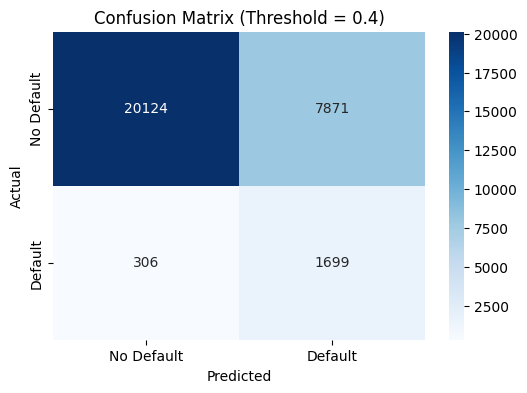


Plotting Feature Importances...


C:\Users\Adhithya\AppData\Local\Temp\ipykernel_28772\359913361.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


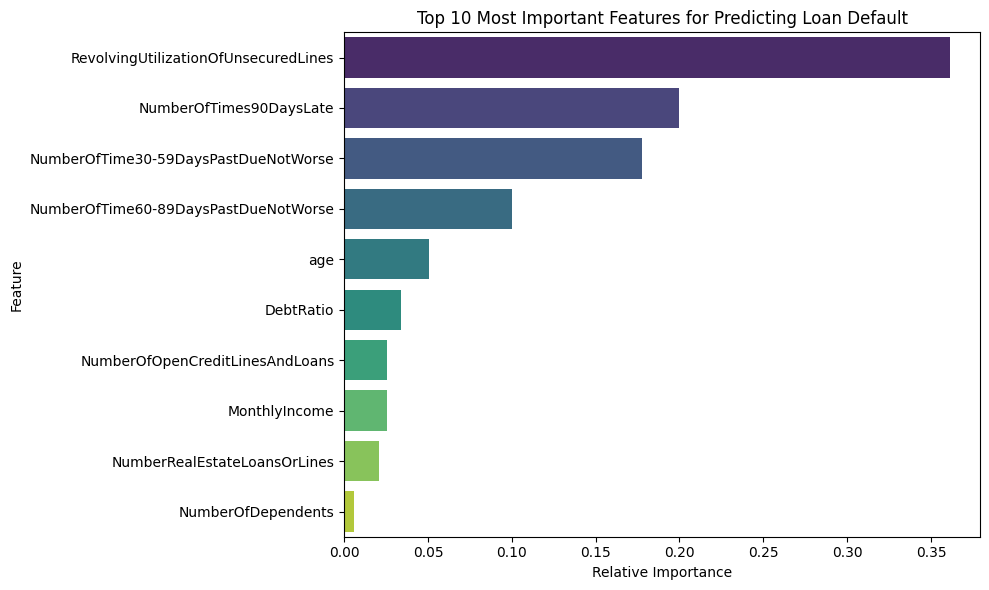

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("\n--- Standard Evaluation (50% Threshold) ---")
y_pred = best_rf.predict(X_test)
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

custom_threshold = 0.40
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

print(f"\n--- Evaluation with Custom Threshold ({custom_threshold * 100}%) ---")
print(classification_report(y_test, y_pred_custom))

cm = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Default', 'Default'], 
            yticklabels=['No Default', 'Default'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title(f'Confusion Matrix (Threshold = {custom_threshold})')
plt.show()

print("\nPlotting Feature Importances...")
importances = best_rf.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Most Important Features for Predicting Loan Default')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()